In [30]:
!pip install pulp matplotlib ace-tools-open pandas

In [31]:
import pandas as pd
import ace_tools_open as tool
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpStatus

In [32]:
schedule_data = {
    "week_days": ("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"),
    "employees": {
        "Piotr": {
            "hourly_rate": 30,
            "max_weekly_hours": 20,
            "working_days": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
        },
        "Barbara": {
            "hourly_rate": 50,
            "max_weekly_hours": 80,
            "working_days": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
        },
        "Zenon": {
            "hourly_rate": 40,
            "max_weekly_hours": 45,
            "working_days": ["Monday", "Tuesday", "Wednesday", "Saturday", "Sunday"]
        }
    }
}


In [33]:
optimization_model = LpProblem("Employee_Scheduling", LpMinimize)

working_hours = {emp: [LpVariable(f"{emp}_hrs_{day}", lowBound=0, upBound=10, cat="Integer")
                       for day in schedule_data["week_days"]]
                 for emp in schedule_data["employees"]}

is_working = {emp: [LpVariable(f"{emp}_works_{day}", cat="Binary")
                     for day in schedule_data["week_days"]]
              for emp in schedule_data["employees"]}


Employee Schedule


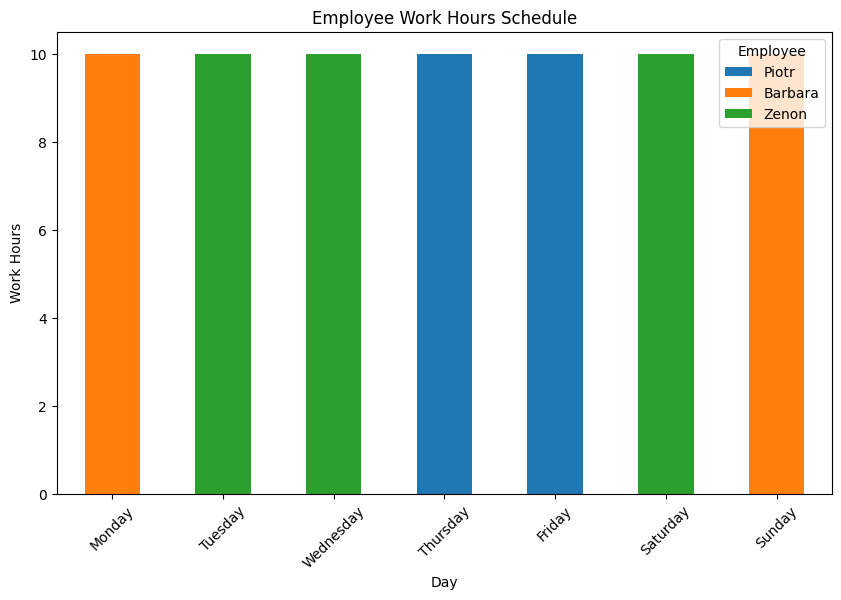

In [34]:

optimization_model += lpSum(
    lpSum(working_hours[emp]) * schedule_data["employees"][emp]["hourly_rate"]
    for emp in schedule_data["employees"]
), "Total_Cost"

for i, day in enumerate(schedule_data["week_days"]):
    optimization_model += lpSum(working_hours[emp][i] for emp in schedule_data["employees"]) == 10, f"Daily_Hours_{day}"

for emp, details in schedule_data["employees"].items():
    for i, day in enumerate(schedule_data["week_days"]):
        if day not in details["working_days"]:
            optimization_model += working_hours[emp][i] == 0, f"{emp}_Not_Available_{day}"

        optimization_model += working_hours[emp][i] >= is_working[emp][i] * 5, f"{emp}_Min_Hours_{day}"

        optimization_model += working_hours[emp][i] <= is_working[emp][i] * 10, f"{emp}_Max_Hours_{day}"

    optimization_model += lpSum(is_working[emp]) <= 3, f"{emp}_Max_Days_Worked"

    optimization_model += lpSum(working_hours[emp]) <= details["max_weekly_hours"], f"{emp}_Weekly_Limit"

optimization_model.solve()

schedule_results = {day: {} for day in schedule_data["week_days"]}
for emp in schedule_data["employees"]:
    for i, day in enumerate(schedule_data["week_days"]):
        schedule_results[day][emp] = working_hours[emp][i].varValue if working_hours[emp][i].varValue else 0

schedule_df = pd.DataFrame(schedule_results)


tool.display_dataframe_to_user(name="Employee Schedule", dataframe=schedule_df)

schedule_df.T.plot(kind="bar", figsize=(10, 6), stacked=True, title="Employee Work Hours Schedule")
plt.xlabel("Day")
plt.ylabel("Work Hours")
plt.legend(title="Employee")
plt.xticks(rotation=45)
plt.show()
